# Distillation Teacher Sweep — v2 vs v3 Comparison

Compares students trained on **v2** vs **v3** reasoning traces for **Gemma 3 27B** (no internal reasoning).

Since Gemma does not support chain-of-thought reasoning, the v2→v3 difference isolates the impact of the **new prompt format** only.

In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

plt.rcParams["figure.dpi"] = 120

In [6]:
DATA_DIR = Path("../data/safety_experiment/pipeline")
FIGS_DIR = Path("../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Teacher directory slugs → version label
VERSIONS = {
    "RedHatAI-gemma-3-27b-it-quantized.w4a16":      "v2",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16-v3":   "v3",
}

DATASETS = {
    "annotated-intents": "Annotated Intents",
    "wildguardmix":      "WildguardTest",
    "xstest":            "XSTest",
}

CONDITIONS = {
    "finetuned_reasoning_classification": "Without Intent",
    "finetuned_reasoning_generation":     "With Intent",
}

DATASET_ORDER    = ["Annotated Intents", "WildguardTest", "XSTest", "Average"]
CONDITION_ORDER  = ["Without Intent", "With Intent"]
VERSION_COLORS   = {"v2": "#4393c3", "v3": "#d6604d"}

## Prompt format: v2 vs v3

The teacher always sees the full instruction. The change between versions is in the **student** prompt.

**v2 — student input:** raw prompt only
```
<user prompt>
```
↓
```
Reasoning: ...
[Intent: ...]
Prompt harm: harmful/unharmful
```

---

**v3 — student input:** classifier instruction + taxonomy + output format + prompt
```
You are a classifier for analyzing interactions between humans and LLMs. Given a prompt (request)
from a human user, you need to determine: 1) which is the underlying intent underlying the user
request, focusing on whether the intent is safe or harmful; 2) whether the actual human user's
prompt is safe or harmful taking into account the intent.
The intent should be a kind of summary of the user request, focusing on its core purpose or goal
and taking into account mainly the safety of the user request. When reasoning about the intent and
the final label of the user prompt, use the safety taxonomy below.

Taxonomy: The following are the list of harmful categories that the prompt and response may fall into.

Privacy: ...  Misinformation: ...  Harmful language: ...  Malicious uses: ...

Human user:
<user prompt>

Use the taxonomy to determine the final harm label for the prompt. Output your answer in the
following format: ...
```
↓
```
Reasoning: ...
[Intent: ...]
Prompt harm: harmful/unharmful
```

---

The v2→v3 gap for Gemma 3 27B (which has **no internal chain-of-thought**) therefore reflects the impact of giving the student the full task instruction at both training and inference time.

## Compute F1 from prediction files

In [7]:
def compute_metrics(path: Path) -> dict:
    records = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    # Drop entries where prediction failed (None)
    before = len(records)
    records = [r for r in records if r.get("predicted_harm") is not None]
    dropped = before - len(records)
    if dropped:
        print(f"  [{path.parent.parent.name}/{path.parent.name}] dropped {dropped}/{before} unparsed predictions")
    y_true = [r["true_harm_binary"] for r in records]
    y_pred = [r["predicted_harm"]   for r in records]
    return {
        "f1":        f1_score(y_true, y_pred, pos_label="harmful"),
        "precision": precision_score(y_true, y_pred, pos_label="harmful", zero_division=0),
        "recall":    recall_score(y_true, y_pred, pos_label="harmful", zero_division=0),
    }


rows = []
for slug, version in VERSIONS.items():
    for ds_key, ds_name in DATASETS.items():
        for cond_key, cond_name in CONDITIONS.items():
            fname = f"meta-llama_Llama-3.1-8B-Instruct_{cond_key}.jsonl"
            fpath = DATA_DIR / slug / ds_key / fname
            if not fpath.exists():
                print(f"MISSING: {fpath}")
                continue
            metrics = compute_metrics(fpath)
            rows.append({"version": version, "condition": cond_name, "dataset": ds_name, **metrics})

df = pd.DataFrame(rows)

# Add Average row (mean across 3 datasets per version×condition)
avg_rows = (
    df.groupby(["version", "condition"])[["f1", "precision", "recall"]]
    .mean()
    .reset_index()
)
avg_rows["dataset"] = "Average"
df = pd.concat([df, avg_rows], ignore_index=True)

df

  [RedHatAI-gemma-3-27b-it-quantized.w4a16/annotated-intents] dropped 4/172 unparsed predictions
  [RedHatAI-gemma-3-27b-it-quantized.w4a16/wildguardmix] dropped 26/1699 unparsed predictions
  [RedHatAI-gemma-3-27b-it-quantized.w4a16/xstest] dropped 1/450 unparsed predictions
  [RedHatAI-gemma-3-27b-it-quantized.w4a16-v3/wildguardmix] dropped 3/1699 unparsed predictions
  [RedHatAI-gemma-3-27b-it-quantized.w4a16-v3/xstest] dropped 1/450 unparsed predictions


,version,condition,dataset,f1,precision,recall
0,v2,Without Intent,Annotated Intents,0.732558,0.715909,0.750000
1,v2,With Intent,Annotated Intents,0.670968,0.722222,0.626506
2,v2,Without Intent,WildguardTest,0.837057,0.829427,0.844828
3,v2,With Intent,WildguardTest,0.839018,0.856546,0.822193
4,v2,Without Intent,XSTest,0.875576,0.811966,0.950000
5,v2,With Intent,XSTest,0.866359,0.803419,0.940000
6,v3,Without Intent,Annotated Intents,0.742515,0.746988,0.738095
7,v3,With Intent,Annotated Intents,0.742515,0.746988,0.738095
8,v3,Without Intent,WildguardTest,0.828947,0.822454,0.835544
9,v3,With Intent,WildguardTest,0.850836,0.855989,0.845745


## v2 vs v3 — F1 by dataset and condition

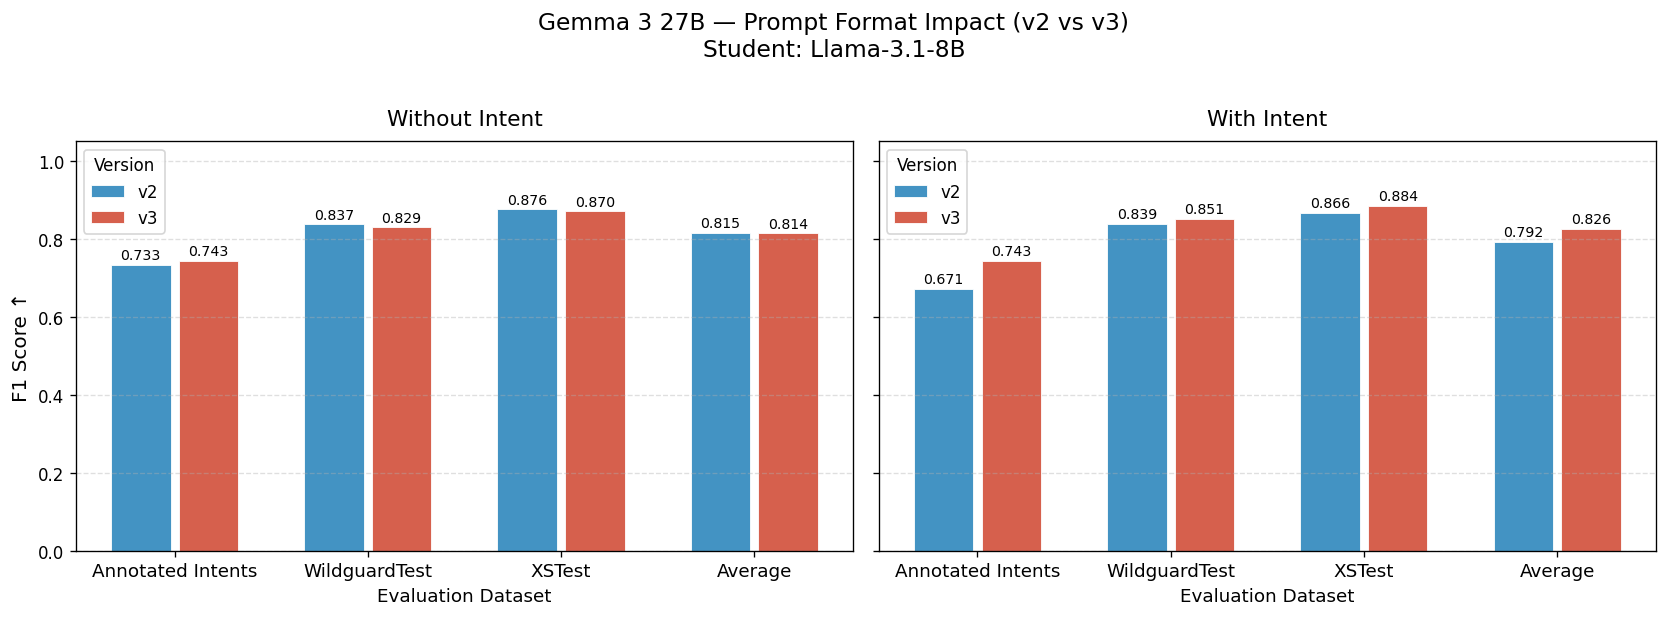

In [8]:
versions = ["v2", "v3"]
bar_w   = 0.35
x       = np.arange(len(DATASET_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, condition in zip(axes, CONDITION_ORDER):
    df_c = df[df["condition"] == condition]

    for i, version in enumerate(versions):
        df_cv = df_c[df_c["version"] == version].set_index("dataset")
        f1_vals = [df_cv.loc[ds, "f1"] if ds in df_cv.index else 0.0 for ds in DATASET_ORDER]
        offset  = (i - 0.5) * bar_w

        bars = ax.bar(
            x + offset, f1_vals, bar_w * 0.88,
            label=version,
            color=VERSION_COLORS[version],
            edgecolor="white", linewidth=0.5,
        )
        for bar, v in zip(bars, f1_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.007,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=8.5,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, fontsize=11)
    ax.set_title(condition, fontsize=13, pad=10)
    ax.set_xlabel("Evaluation Dataset", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Version", fontsize=10, title_fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("F1 Score ↑", fontsize=12)

fig.suptitle(
    "Gemma 3 27B — Prompt Format Impact (v2 vs v3)\nStudent: Llama-3.1-8B",
    fontsize=14, y=1.02,
)
plt.tight_layout()
fig.savefig(FIGS_DIR / "gemma_v2_v3_f1.pdf", bbox_inches="tight")
plt.show()

## Detailed metrics table

In [ ]:
fmt = df.copy()
for col in ["f1", "precision", "recall"]:
    fmt[col] = fmt[col].apply(lambda v: f"{v:.4f}")

fmt[["version", "condition", "dataset", "f1", "precision", "recall"]].sort_values(
    ["condition", "dataset", "version"]
).reset_index(drop=True)